In [11]:
import sys
import subprocess

# --- Check Python version ---
major, minor = sys.version_info[:2]

if not (major == 3 and minor == 12):
    print(f"❌ Python {major}.{minor} detected.")
    print("Please change the Colab runtime to **Python 3.12**:")
    print("Runtime → Change runtime type → Runtime version → 2025.10")
    raise SystemExit

print(f"✅ Python {major}.{minor} detected (OK).")

# --- Check pip version ---
pip_version_output = subprocess.check_output(["pip", "--version"]).decode()
pip_version = pip_version_output.split()[1]  # e.g. "25.0"

print(f"Detected pip version: {pip_version}")

if not pip_version.startswith("25"):
    print("❌ pip version is not 25.x. Installing pip 25...")
    !pip install --upgrade pip==25.*
    print("✅ pip 25 installed.")
    print("Please RESTART the runtime now (Runtime → Restart session).")
else:
    print("✅ pip 25.x is already installed.")

✅ Python 3.12 detected (OK).
Detected pip version: 25.3
✅ pip 25.x is already installed.


In [12]:
# install iqm-client with qrisp extras
!pip install -U "iqm-client==33.0.5" "qrisp[iqm]"
# used for visualization
!pip install matplotlib

from qrisp.interface import IQMBackend

# Set use_timeslot=True if you have booked a timeslot
quantum_computer = IQMBackend(
    api_token = input("IQM Resonance API token"),
    device_instance = "garnet",
    use_timeslot=False)

IQM Resonance API token+qq3UGPdpGSi+mvmuhlDJxVpfChjB4/UoT9sQVRLuPwBniWq68Z8ApYfMZknLsHE 


After successfully installing the required packages and initializing the backend, you can submit the quantum circuit.


In [14]:
from qrisp import *
from matplotlib import pyplot as plt

#Implementation of Grover's algorithm.
#Target state (01)
qv = QuantumVariable(3)

x(qv[2]) #Swap encilla input to 1

#Hademard puts all bits in superposition
h(qv[0])
h(qv[1])
h(qv[2])

#Oracle
x(qv[0])

mcx(qv[0:2], qv[2])

x(qv[0])

#Amplitude amplification
h(qv[0])
x(qv[1])
z(qv[0])

cx(qv[0],qv[1])

h(qv[0])

#Adding Hademard to encilla bit
h(qv[2])

print (qv)
print(qv.qs)

{'011': 1.0}
QuantumCircuit:
---------------
      ┌───┐┌───┐     ┌───┐┌───┐┌───┐     ┌───┐
qv.0: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ Z ├──■──┤ H ├
      ├───┤└───┘  │  ├───┤└───┘└───┘┌─┴─┐└───┘
qv.1: ┤ H ├───────■──┤ X ├──────────┤ X ├─────
      ├───┤┌───┐┌─┴─┐├───┤          └───┘     
qv.2: ┤ X ├┤ H ├┤ X ├┤ H ├────────────────────
      └───┘└───┘└───┘└───┘                    
Live QuantumVariables:
----------------------
QuantumVariable qv


{'110': 0.703, '010': 0.109, '111': 0.058, '100': 0.044, '011': 0.029, '101': 0.025, '000': 0.022, '001': 0.01}


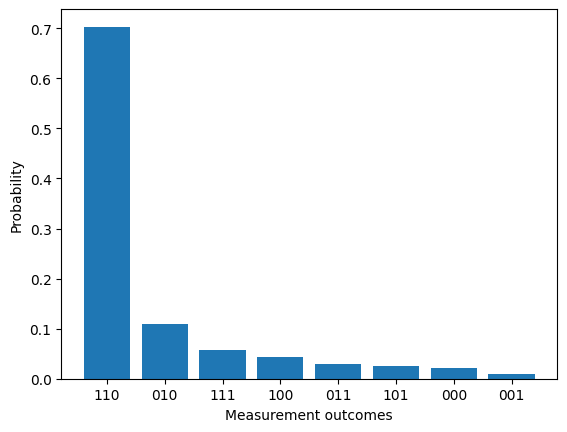

In [15]:
#Execute on the quantum computing backend
#Transpilation is taken care of automatically

result = qv.get_measurement(backend = quantum_computer)

#run1

#Print and plot the result
print(result)

plt.bar(result.keys(), result.values())
plt.xlabel('Measurement outcomes')
plt.ylabel('Probability')
plt.show()

{'110': 0.672, '100': 0.101, '010': 0.087, '111': 0.038, '011': 0.03, '000': 0.028, '001': 0.024, '101': 0.02}


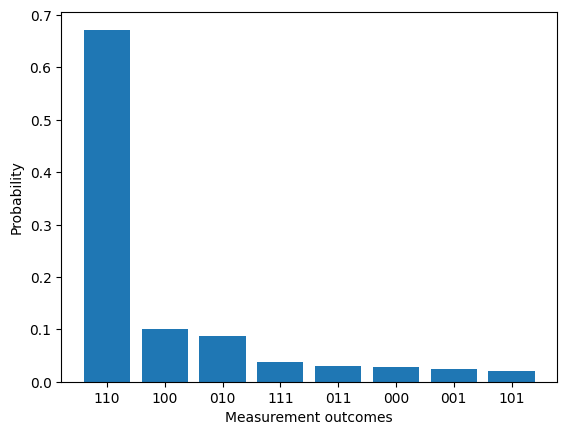

In [16]:
#Execute on the quantum computing backend
#Transpilation is taken care of automatically

result = qv.get_measurement(backend = quantum_computer)

#run2

#Print and plot the result
print(result)

plt.bar(result.keys(), result.values())
plt.xlabel('Measurement outcomes')
plt.ylabel('Probability')
plt.show()

{'110': 0.736, '100': 0.067, '010': 0.047, '111': 0.043, '000': 0.035, '101': 0.03, '011': 0.029, '001': 0.013}


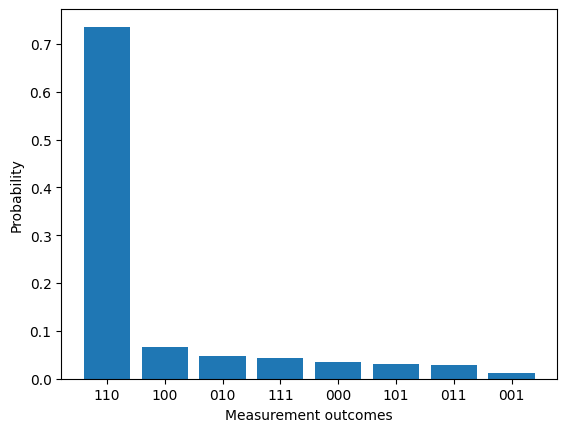

In [17]:
#Execute on the quantum computing backend
#Transpilation is taken care of automatically

result = qv.get_measurement(backend = quantum_computer)

#run3

#Print and plot the result
print(result)

plt.bar(result.keys(), result.values())
plt.xlabel('Measurement outcomes')
plt.ylabel('Probability')
plt.show()

{'110': 0.817, '111': 0.056, '100': 0.038, '010': 0.036, '101': 0.021, '000': 0.012, '001': 0.01, '011': 0.01}


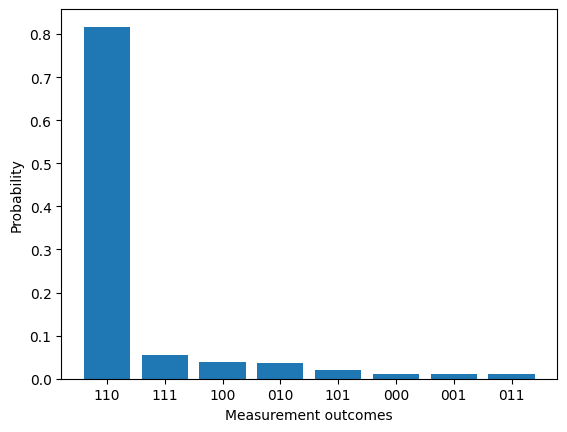

In [18]:
#Execute on the quantum computing backend
#Transpilation is taken care of automatically

result = qv.get_measurement(backend = quantum_computer)

#run4

#Print and plot the result
print(result)

plt.bar(result.keys(), result.values())
plt.xlabel('Measurement outcomes')
plt.ylabel('Probability')
plt.show()

{'110': 0.785, '111': 0.056, '100': 0.046, '010': 0.035, '101': 0.034, '011': 0.016, '000': 0.014, '001': 0.014}


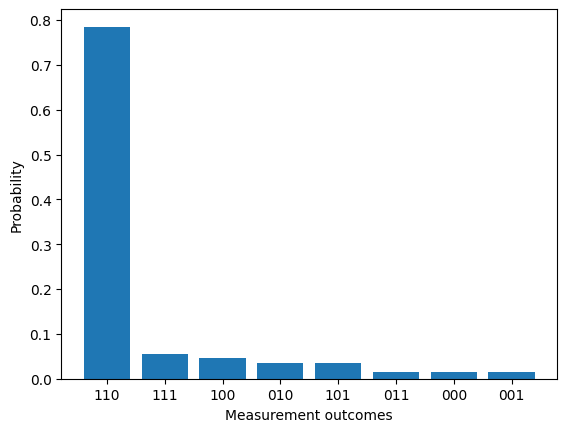

In [19]:
#Execute on the quantum computing backend
#Transpilation is taken care of automatically

result = qv.get_measurement(backend = quantum_computer)

#run5

#Print and plot the result
print(result)

plt.bar(result.keys(), result.values())
plt.xlabel('Measurement outcomes')
plt.ylabel('Probability')
plt.show()